In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────
customers = pd.read_csv("customers.csv")
products  = pd.read_csv("products.csv")
sales     = pd.read_csv("sales.csv")

# ── Apply Cleaning ─────────────────────────────────────────
customers['Date_of_Birth']     = pd.to_datetime(customers['Date_of_Birth'])
customers['Registration_Date'] = pd.to_datetime(customers['Registration_Date'])
sales['Order_Date']            = pd.to_datetime(sales['Order_Date'])
sales['Delivery_Date']         = pd.to_datetime(sales['Delivery_Date'])
sales['Coupon_Code']           = sales['Coupon_Code'].fillna('No Coupon')
sales['Has_Review']            = sales['Rating'].notna().astype(int)
sales                          = sales[sales['Total_Amount'] >= 0]

# ── Shared Plot Style ──────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     15,
    'figure.dpi':        150,
})

print(" Setup complete.")
print(f"   Customers : {customers.shape}")
print(f"   Products  : {products.shape}")
print(f"   Sales     : {sales.shape}")

 Setup complete.
   Customers : (40000, 15)
   Products  : (2000, 12)
   Sales     : (249995, 22)


HYPOTHESIS 1: UPI vs COD Order Value (t-test)

UPI Orders  : 128,471
COD Orders  : 82,091

UPI Mean    : ₹24,724.78
COD Mean    : ₹22,437.40

UPI Std Dev : ₹38,181.35
COD Std Dev : ₹36,069.14

Levene Test : stat=129.0252, p=0.0000
Equal Variance Assumed: False

t-statistic : 13.8704
p-value     : 0.000000

Significance level (α) : 0.05
Decision    :  REJECT H₀
Conclusion  : UPI and COD users have significantly
              different mean order values.

95% CI for difference in means:
   [₹1,964.15  to  ₹2,610.60]


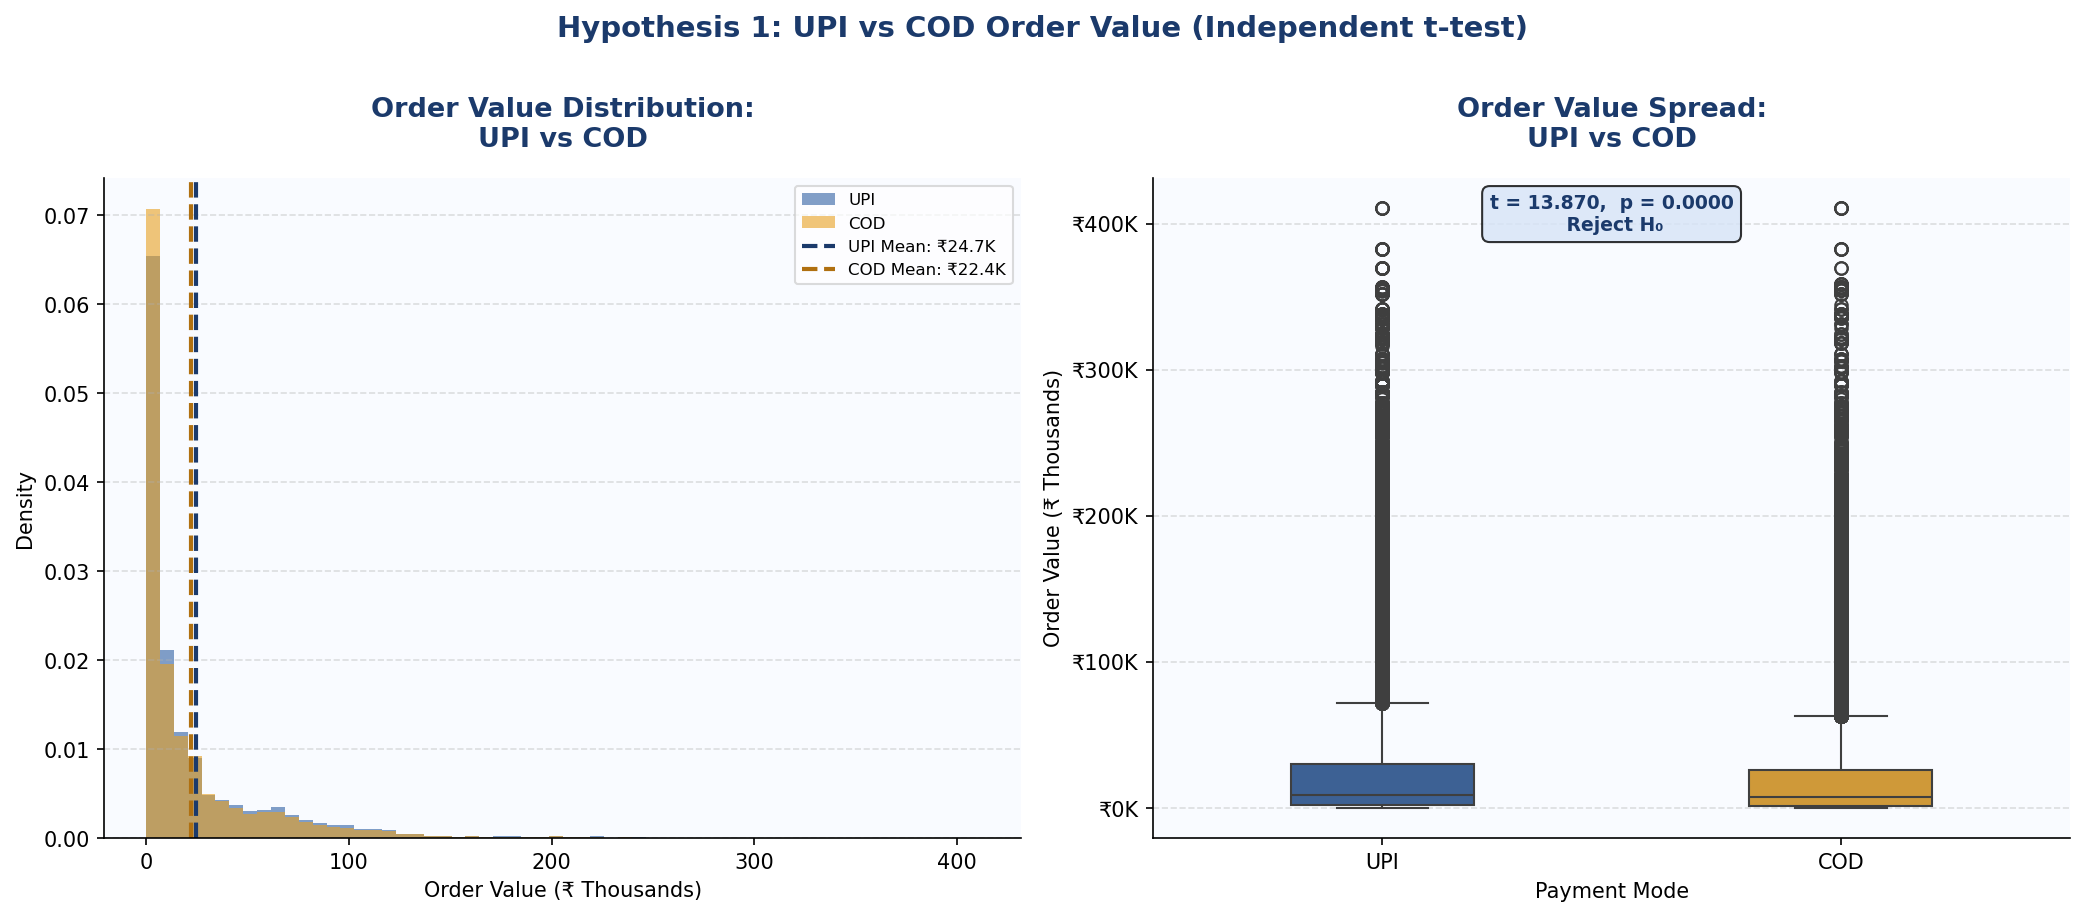


 H1 visualization saved.


In [3]:
# ── HYPOTHESIS 1: UPI vs COD Average Order Value ───────────
# H₀: There is no significant difference in mean order value
#     between UPI and COD users
# H₁: UPI users have a significantly higher mean order value
#     than COD users

print("=" * 55)
print("HYPOTHESIS 1: UPI vs COD Order Value (t-test)")
print("=" * 55)

# ── Prepare Data ───────────────────────────────────────────
upi_orders = sales[sales['Payment_Mode'] == 'UPI']['Total_Amount']
cod_orders = sales[sales['Payment_Mode'] == 'COD']['Total_Amount']

print(f"\nUPI Orders  : {len(upi_orders):,}")
print(f"COD Orders  : {len(cod_orders):,}")
print(f"\nUPI Mean    : ₹{upi_orders.mean():,.2f}")
print(f"COD Mean    : ₹{cod_orders.mean():,.2f}")
print(f"\nUPI Std Dev : ₹{upi_orders.std():,.2f}")
print(f"COD Std Dev : ₹{cod_orders.std():,.2f}")

# ── Levene Test (check equal variance assumption) ──────────
levene_stat, levene_p = stats.levene(upi_orders, cod_orders)
print(f"\nLevene Test : stat={levene_stat:.4f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05
print(f"Equal Variance Assumed: {equal_var}")

# ── Independent t-test ─────────────────────────────────────
t_stat, p_value = stats.ttest_ind(upi_orders, cod_orders,
                                   equal_var=equal_var)
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"\nSignificance level (α) : 0.05")

if p_value < 0.05:
    print("Decision    :  REJECT H₀")
    print("Conclusion  : UPI and COD users have significantly")
    print("              different mean order values.")
else:
    print("Decision    :  FAIL TO REJECT H₀")
    print("Conclusion  : No significant difference found.")

# ── Confidence Interval ────────────────────────────────────
diff_mean = upi_orders.mean() - cod_orders.mean()
se = np.sqrt(upi_orders.var()/len(upi_orders) +
             cod_orders.var()/len(cod_orders))
ci_low  = diff_mean - 1.96 * se
ci_high = diff_mean + 1.96 * se
print(f"\n95% CI for difference in means:")
print(f"   [₹{ci_low:,.2f}  to  ₹{ci_high:,.2f}]")

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Distribution comparison
ax1 = axes[0]
ax1.hist(upi_orders / 1000, bins=60, alpha=0.6,
         color='#2E5FA3', label='UPI', density=True)
ax1.hist(cod_orders / 1000, bins=60, alpha=0.6,
         color='#E8A020', label='COD', density=True)
ax1.axvline(upi_orders.mean() / 1000, color='#1B3A6B',
            linestyle='--', linewidth=2,
            label=f'UPI Mean: ₹{upi_orders.mean()/1000:.1f}K')
ax1.axvline(cod_orders.mean() / 1000, color='#B07010',
            linestyle='--', linewidth=2,
            label=f'COD Mean: ₹{cod_orders.mean()/1000:.1f}K')
ax1.set_title('Order Value Distribution:\nUPI vs COD',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Order Value (₹ Thousands)', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend(fontsize=8, framealpha=0.7)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_facecolor('#F9FBFF')

# Right — Box plot comparison
ax2 = axes[1]
plot_data = pd.DataFrame({
    'Order Value (₹K)': pd.concat([upi_orders, cod_orders]) / 1000,
    'Payment Mode':     ['UPI'] * len(upi_orders) +
                        ['COD'] * len(cod_orders)
})
sns.boxplot(data=plot_data, x='Payment Mode',
            y='Order Value (₹K)',
            hue='Payment Mode',
            palette={'UPI': '#2E5FA3', 'COD': '#E8A020'},
            width=0.4, legend=False, ax=ax2)

# Annotate p-value
ax2.text(0.5, 0.92,
         f't = {t_stat:.3f},  p = {p_value:.4f}\n'
         f'{" Reject H₀" if p_value < 0.05 else " Fail to Reject H₀"}',
         transform=ax2.transAxes, ha='center',
         fontsize=9, color='#1B3A6B', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#D6E4F7', alpha=0.8))

ax2.set_title('Order Value Spread:\nUPI vs COD',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_ylabel('Order Value (₹ Thousands)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fK'))
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

fig.suptitle('Hypothesis 1: UPI vs COD Order Value (Independent t-test)',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.01)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('h1_upi_vs_cod.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n H1 visualization saved.")

HYPOTHESIS 2: Order Status vs Payment Mode (Chi-Square)

Contingency Table:
Order_Status  Cancelled  Delivered  Processing  Returned  Shipped
Payment_Mode                                                     
COD                4023      65677        4064      4184     4143
Credit Card         530       8490         510       540      507
Debit Card         1453      23124        1447      1447     1385
UPI                6500     102844        6381      6322     6424

Chi-Square Statistic : 10.1623
Degrees of Freedom   : 12
p-value              : 0.601724

Significance level (α) : 0.05
Decision    :  FAIL TO REJECT H₀
Conclusion  : No significant association found.

Cramér's V (Effect Size) : 0.0037
Effect Size : Weak association


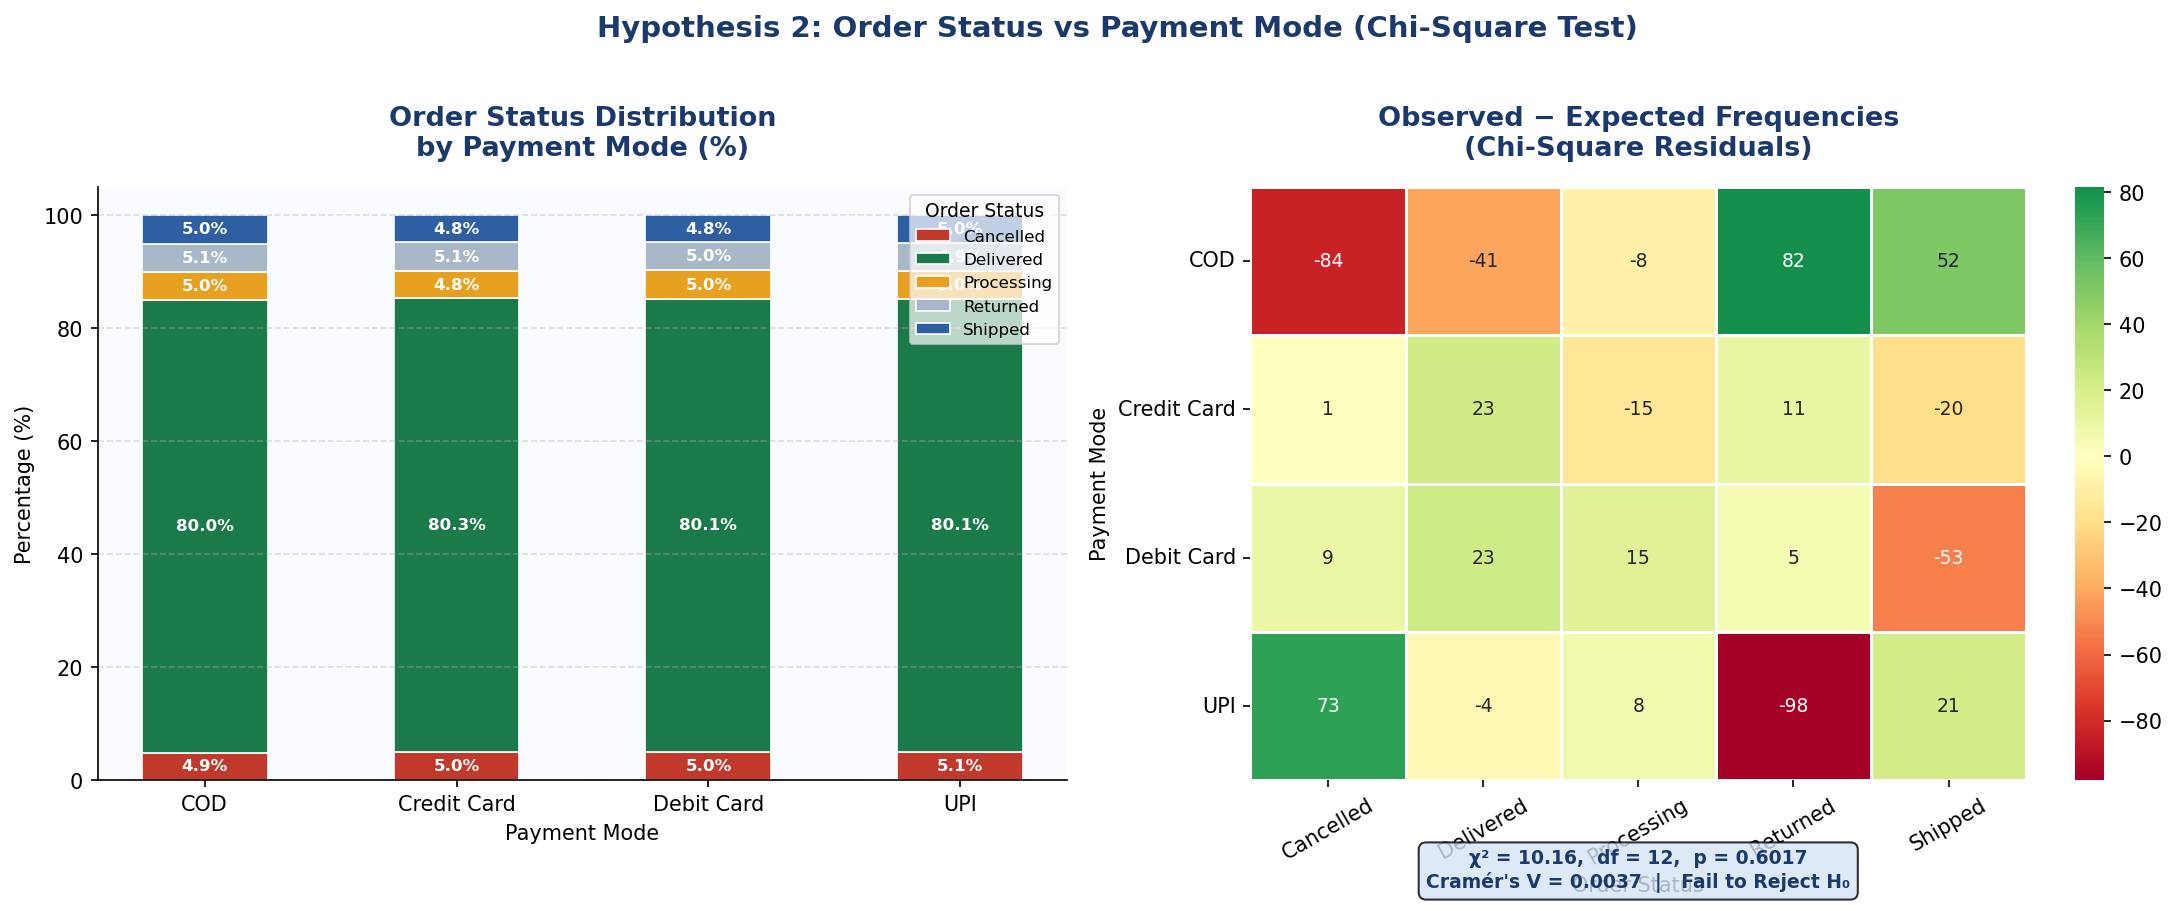


 H2 visualization saved.


In [4]:
# ── HYPOTHESIS 2: Order Status vs Payment Mode ─────────────
# H₀: Order status is independent of payment mode
# H₁: Order status and payment mode are significantly
#     associated with each other

print("=" * 55)
print("HYPOTHESIS 2: Order Status vs Payment Mode (Chi-Square)")
print("=" * 55)

# ── Contingency Table ──────────────────────────────────────
contingency = pd.crosstab(sales['Payment_Mode'],
                           sales['Order_Status'])
print("\nContingency Table:")
print(contingency)

# ── Chi-Square Test ────────────────────────────────────────
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"p-value              : {p_value:.6f}")
print(f"\nSignificance level (α) : 0.05")

if p_value < 0.05:
    print("Decision    :  REJECT H₀")
    print("Conclusion  : Order status and payment mode are")
    print("              significantly associated.")
else:
    print("Decision    :  FAIL TO REJECT H₀")
    print("Conclusion  : No significant association found.")

# ── Cramér's V (effect size) ───────────────────────────────
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"\nCramér's V (Effect Size) : {cramers_v:.4f}")
if cramers_v < 0.1:
    print("Effect Size : Weak association")
elif cramers_v < 0.3:
    print("Effect Size : Moderate association")
else:
    print("Effect Size : Strong association")

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left — Stacked percentage bar chart
ax1 = axes[0]
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

status_colors = {
    'Delivered':  '#1A7A4A',
    'Shipped':    '#2E5FA3',
    'Processing': '#E8A020',
    'Cancelled':  '#C0392B',
    'Returned':   '#A8B8C8',
}

bottom = np.zeros(len(contingency_pct))
for status in contingency_pct.columns:
    color = status_colors.get(status, '#888888')
    bars = ax1.bar(contingency_pct.index,
                   contingency_pct[status],
                   bottom=bottom,
                   label=status,
                   color=color,
                   edgecolor='white',
                   linewidth=0.8,
                   width=0.5)
    for bar, val in zip(bars, contingency_pct[status]):
        if val > 4:
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}%',
                     ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottom += contingency_pct[status].values

ax1.set_title('Order Status Distribution\nby Payment Mode (%)',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Payment Mode', fontsize=10)
ax1.set_ylabel('Percentage (%)', fontsize=10)
ax1.legend(title='Order Status', fontsize=8,
           title_fontsize=9, loc='upper right', framealpha=0.7)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_facecolor('#F9FBFF')

# Right — Heatmap of expected vs observed difference
ax2 = axes[1]
expected_df = pd.DataFrame(expected,
                            index=contingency.index,
                            columns=contingency.columns)
diff = contingency - expected_df

sns.heatmap(diff, annot=True, fmt='.0f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax2,
            annot_kws={'size': 9})

ax2.set_title('Observed − Expected Frequencies\n(Chi-Square Residuals)',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_xlabel('Order Status', fontsize=10)
ax2.set_ylabel('Payment Mode', fontsize=10)
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

# Annotate result
ax2.text(0.5, -0.18,
         f'χ² = {chi2:.2f},  df = {dof},  p = {p_value:.4f}'
         f'\nCramér\'s V = {cramers_v:.4f}  |  '
         f'{" Reject H₀" if p_value < 0.05 else " Fail to Reject H₀"}',
         transform=ax2.transAxes, ha='center',
         fontsize=9, color='#1B3A6B', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#D6E4F7', alpha=0.8))

fig.suptitle('Hypothesis 2: Order Status vs Payment Mode (Chi-Square Test)',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('h2_order_status_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n H2 visualization saved.")

HYPOTHESIS 3: Order Value by Customer Tier (ANOVA)

Silver   — Count: 25,359  | Mean: ₹7,372.33  | Std: ₹19,055.66
Gold     — Count: 37,063  | Mean: ₹10,831.44  | Std: ₹18,943.22
Platinum — Count: 187,573  | Mean: ₹28,481.14  | Std: ₹40,490.58

Levene Test : stat=5984.4749, p=0.0000

F-statistic : 6508.9885
p-value     : 0.000000

Significance level (α) : 0.05
Decision    : ✅ REJECT H₀
Conclusion  : At least one customer tier has a
              significantly different mean order value.

Post-hoc Tukey HSD Test:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
 group1   group2    meandiff  p-adj    lower       upper    reject
------------------------------------------------------------------
    Gold Platinum  17649.7009   0.0  17165.6405  18133.7613   True
    Gold   Silver  -3459.1079   0.0  -4153.0893  -2765.1265   True
Platinum   Silver -21108.8088   0.0 -21678.5592 -20539.0585   True
------------------------------------------------------------------

Eta-squared 

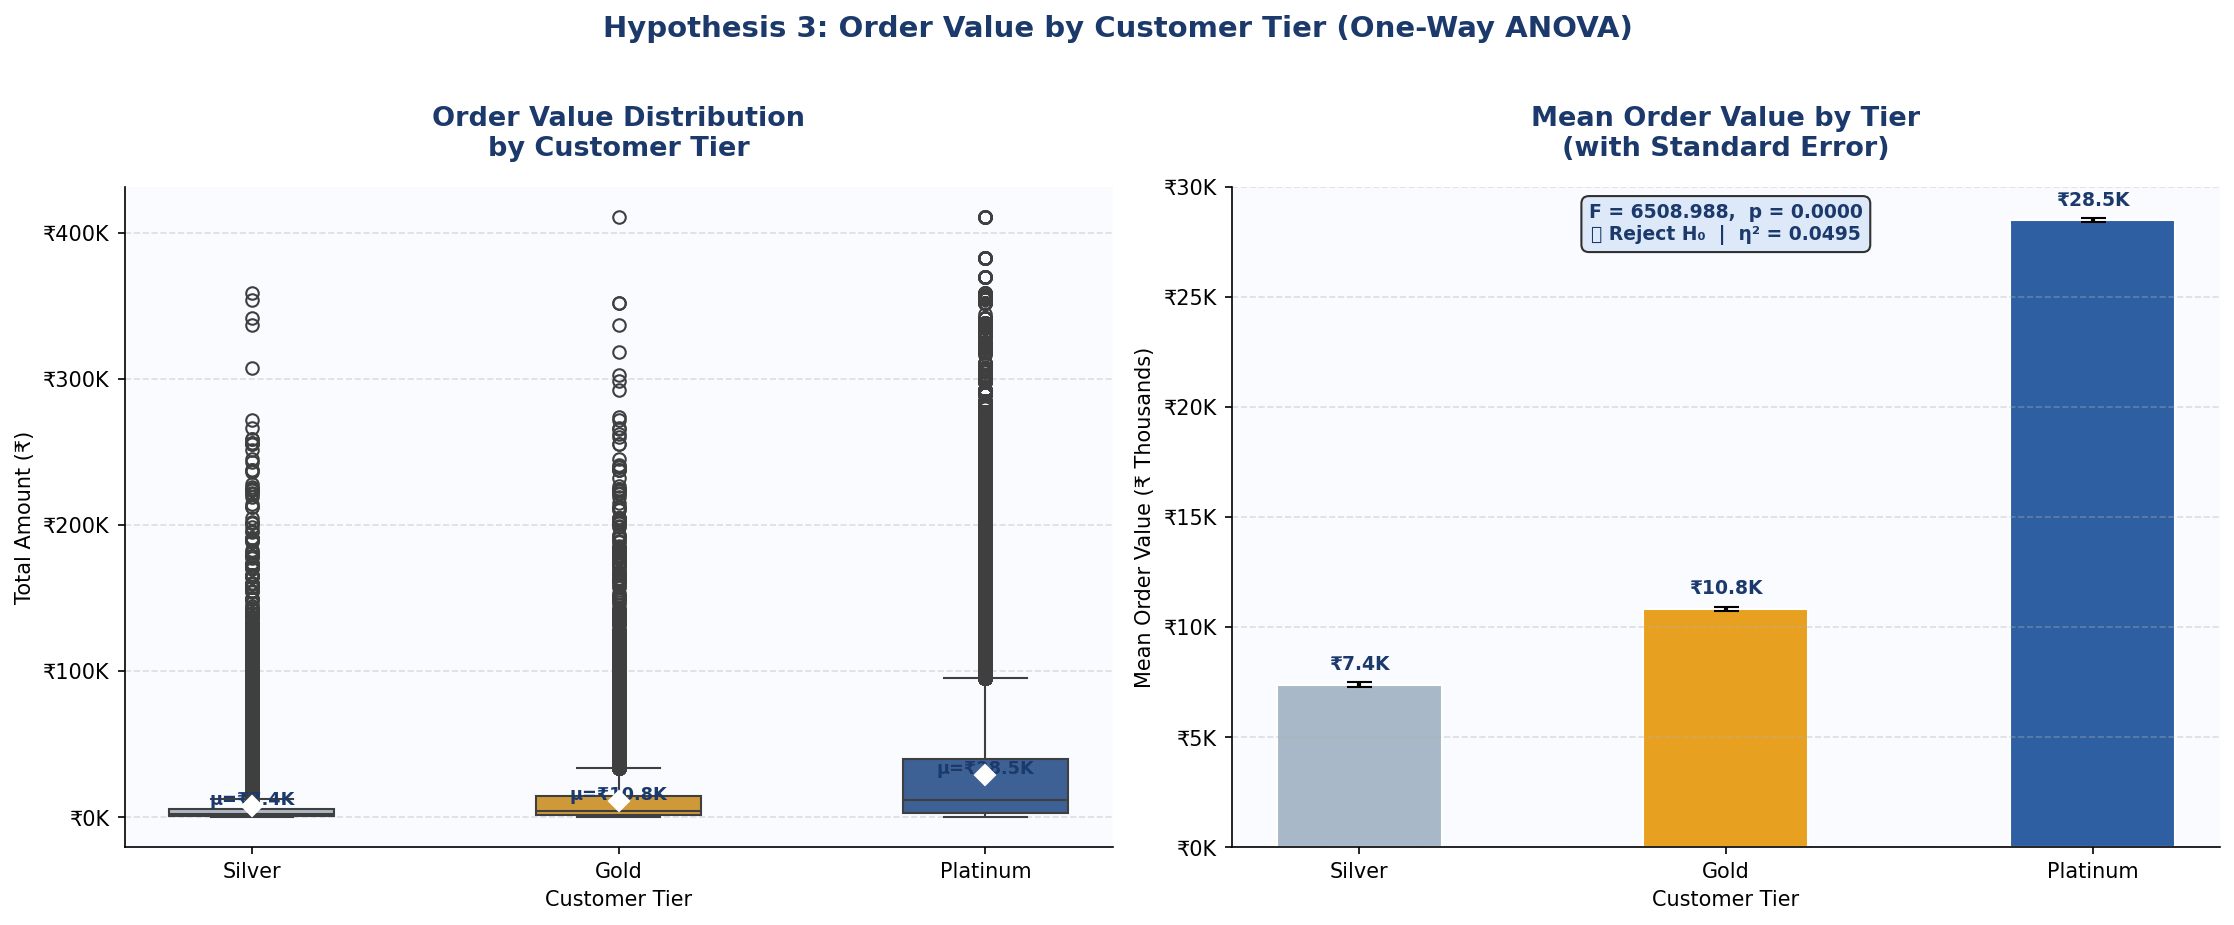


✅ H3 visualization saved.


In [5]:
# ── HYPOTHESIS 3: Order Value across Customer Tiers ────────
# H₀: Mean order value is equal across Silver, Gold,
#     and Platinum customer tiers
# H₁: At least one tier has a significantly different
#     mean order value

print("=" * 55)
print("HYPOTHESIS 3: Order Value by Customer Tier (ANOVA)")
print("=" * 55)

# ── Merge sales with customers to get tier ─────────────────
sales_customers = sales.merge(
    customers[['Customer_ID', 'Customer_Tier']],
    on='Customer_ID', how='left'
)

# ── Group by tier ──────────────────────────────────────────
silver   = sales_customers[sales_customers['Customer_Tier'] == 'Silver']['Total_Amount']
gold     = sales_customers[sales_customers['Customer_Tier'] == 'Gold']['Total_Amount']
platinum = sales_customers[sales_customers['Customer_Tier'] == 'Platinum']['Total_Amount']

print(f"\nSilver   — Count: {len(silver):,}  | Mean: ₹{silver.mean():,.2f}  | Std: ₹{silver.std():,.2f}")
print(f"Gold     — Count: {len(gold):,}  | Mean: ₹{gold.mean():,.2f}  | Std: ₹{gold.std():,.2f}")
print(f"Platinum — Count: {len(platinum):,}  | Mean: ₹{platinum.mean():,.2f}  | Std: ₹{platinum.std():,.2f}")

# ── Levene Test ────────────────────────────────────────────
levene_stat, levene_p = stats.levene(silver, gold, platinum)
print(f"\nLevene Test : stat={levene_stat:.4f}, p={levene_p:.4f}")

# ── One-Way ANOVA ──────────────────────────────────────────
f_stat, p_value = stats.f_oneway(silver, gold, platinum)

print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"\nSignificance level (α) : 0.05")

if p_value < 0.05:
    print("Decision    : ✅ REJECT H₀")
    print("Conclusion  : At least one customer tier has a")
    print("              significantly different mean order value.")
else:
    print("Decision    : ❌ FAIL TO REJECT H₀")
    print("Conclusion  : No significant difference found.")

# ── Post-hoc Tukey HSD ────────────────────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    sales_customers['Total_Amount'],
    sales_customers['Customer_Tier'],
    alpha=0.05
)
print(f"\nPost-hoc Tukey HSD Test:")
print(tukey.summary())

# ── Effect Size (Eta-squared) ──────────────────────────────
grand_mean = sales_customers['Total_Amount'].mean()
ss_between = sum([
    len(g) * (g.mean() - grand_mean) ** 2
    for g in [silver, gold, platinum]
])
ss_total = sum((sales_customers['Total_Amount'] - grand_mean) ** 2)
eta_sq = ss_between / ss_total
print(f"\nEta-squared (Effect Size) : {eta_sq:.6f}")
if eta_sq < 0.01:
    print("Effect Size : Small")
elif eta_sq < 0.06:
    print("Effect Size : Medium")
else:
    print("Effect Size : Large")

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tier_colors = {
    'Silver':   '#A8B8C8',
    'Gold':     '#E8A020',
    'Platinum': '#2E5FA3',
}

# Left — Box plot by tier
ax1 = axes[0]
tier_order = ['Silver', 'Gold', 'Platinum']
plot_data  = sales_customers[
    sales_customers['Customer_Tier'].isin(tier_order)
].copy()

sns.boxplot(data=plot_data,
            x='Customer_Tier', y='Total_Amount',
            hue='Customer_Tier',
            order=tier_order,
            palette=tier_colors,
            width=0.45, legend=False, ax=ax1)

# Mean markers
for i, tier in enumerate(tier_order):
    mean_val = sales_customers[
        sales_customers['Customer_Tier'] == tier
    ]['Total_Amount'].mean()
    ax1.plot(i, mean_val, marker='D', color='white',
             markersize=7, zorder=5)
    ax1.text(i, mean_val + 1200,
             f'μ=₹{mean_val/1000:.1f}K',
             ha='center', fontsize=8.5,
             color='#1B3A6B', fontweight='bold')

ax1.set_title('Order Value Distribution\nby Customer Tier',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Customer Tier', fontsize=10)
ax1.set_ylabel('Total Amount (₹)', fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_facecolor('#F9FBFF')

# Right — Mean bar chart with error bars
ax2 = axes[1]
tier_stats = plot_data.groupby('Customer_Tier')['Total_Amount'].agg(
    ['mean', 'std', 'count']
).reindex(tier_order)
tier_stats['se'] = tier_stats['std'] / np.sqrt(tier_stats['count'])

bars = ax2.bar(tier_order,
               tier_stats['mean'] / 1000,
               yerr=tier_stats['se'] / 1000,
               color=[tier_colors[t] for t in tier_order],
               edgecolor='white', width=0.45,
               capsize=6, error_kw={'linewidth': 2})

for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'₹{bar.get_height():.1f}K',
             ha='center', va='bottom',
             fontsize=9, color='#1B3A6B', fontweight='bold')

ax2.text(0.5, 0.92,
         f'F = {f_stat:.3f},  p = {p_value:.4f}\n'
         f'{"✅ Reject H₀" if p_value < 0.05 else "❌ Fail to Reject H₀"}'
         f'  |  η² = {eta_sq:.4f}',
         transform=ax2.transAxes, ha='center',
         fontsize=9, color='#1B3A6B', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#D6E4F7', alpha=0.8))

ax2.set_title('Mean Order Value by Tier\n(with Standard Error)',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_xlabel('Customer Tier', fontsize=10)
ax2.set_ylabel('Mean Order Value (₹ Thousands)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fK'))
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

fig.suptitle('Hypothesis 3: Order Value by Customer Tier (One-Way ANOVA)',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('h3_tier_anova.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ H3 visualization saved.")


HYPOTHESIS 4: Coupon Users vs Non-Coupon Users (t-test)

Coupon Orders     : 50,180
No Coupon Orders  : 199,815

Coupon Mean       : ₹23,061.68
No Coupon Mean    : ₹23,889.39

Coupon Std Dev    : ₹36,198.18
No Coupon Std Dev : ₹37,529.97

Levene Test : stat=17.2464, p=0.000033
Equal Variance Assumed: False

t-statistic : -4.5453
p-value     : 0.000005

Significance level (α) : 0.05
Decision    : ✅ REJECT H₀
Conclusion  : Coupon users and non-coupon users
              have significantly different
              mean order values.

Difference in Means : ₹-827.71

95% CI for difference in means:
   [₹-1,184.63  to  ₹-470.79]

Cohen's d (Effect Size) : -0.0222
Effect Size : Negligible


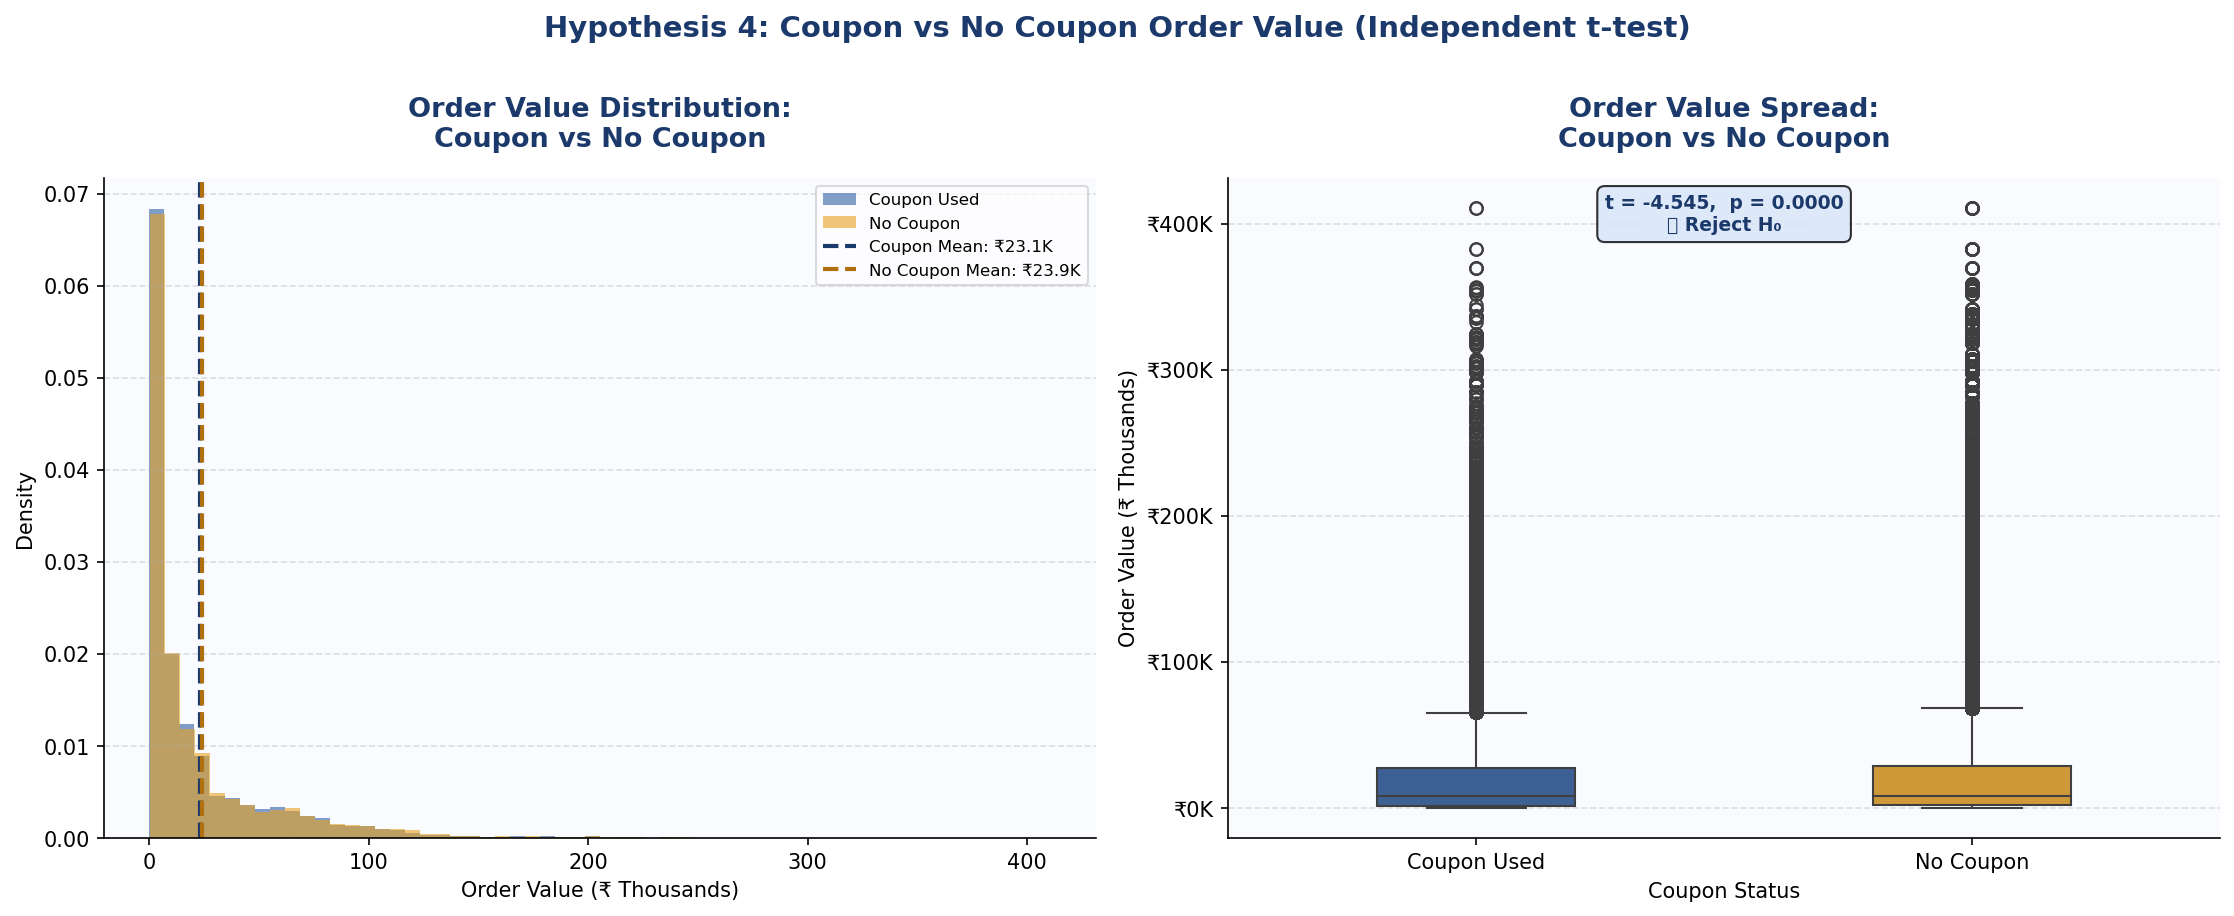


✅ H4 visualization saved.


In [6]:
# ── HYPOTHESIS 4: Coupon Users vs Non-Coupon Users ─────────
# H₀: There is no significant difference in mean order value
#     between coupon users and non-coupon users.
#
# H₁: Customers who use coupons have a significantly higher
#     mean order value than customers who do not use coupons.

print("=" * 55)
print("HYPOTHESIS 4: Coupon Users vs Non-Coupon Users (t-test)")
print("=" * 55)

# ── Prepare Data ────────────────────────────────────────────
coupon_orders = sales[
    sales['Coupon_Code'] != 'No Coupon'
]['Total_Amount'].dropna()

no_coupon_orders = sales[
    sales['Coupon_Code'] == 'No Coupon'
]['Total_Amount'].dropna()

print(f"\nCoupon Orders     : {len(coupon_orders):,}")
print(f"No Coupon Orders  : {len(no_coupon_orders):,}")

print(f"\nCoupon Mean       : ₹{coupon_orders.mean():,.2f}")
print(f"No Coupon Mean    : ₹{no_coupon_orders.mean():,.2f}")

print(f"\nCoupon Std Dev    : ₹{coupon_orders.std():,.2f}")
print(f"No Coupon Std Dev : ₹{no_coupon_orders.std():,.2f}")

# ── Levene Test ────────────────────────────────────────────
# Checks whether the two groups have equal variance.
levene_stat, levene_p = stats.levene(
    coupon_orders,
    no_coupon_orders
)

print(
    f"\nLevene Test : stat={levene_stat:.4f}, "
    f"p={levene_p:.6f}"
)

equal_var = levene_p > 0.05

print(f"Equal Variance Assumed: {equal_var}")

# ── Independent t-test ─────────────────────────────────────
# Welch's t-test is used automatically when variances are unequal.
t_stat, p_value = stats.ttest_ind(
    coupon_orders,
    no_coupon_orders,
    equal_var=equal_var
)

print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"\nSignificance level (α) : 0.05")

if p_value < 0.05:
    print("Decision    : ✅ REJECT H₀")
    
    if coupon_orders.mean() > no_coupon_orders.mean():
        print("Conclusion  : Coupon users have a significantly")
        print("              higher mean order value.")
    else:
        print("Conclusion  : Coupon users and non-coupon users")
        print("              have significantly different")
        print("              mean order values.")
else:
    print("Decision    : ❌ FAIL TO REJECT H₀")
    print("Conclusion  : No significant difference found.")

# ── Mean Difference ─────────────────────────────────────────
diff_mean = coupon_orders.mean() - no_coupon_orders.mean()

print(f"\nDifference in Means : ₹{diff_mean:,.2f}")

# ── 95% Confidence Interval ────────────────────────────────
se = np.sqrt(
    coupon_orders.var() / len(coupon_orders)
    +
    no_coupon_orders.var() / len(no_coupon_orders)
)

ci_low = diff_mean - 1.96 * se
ci_high = diff_mean + 1.96 * se

print("\n95% CI for difference in means:")
print(f"   [₹{ci_low:,.2f}  to  ₹{ci_high:,.2f}]")

# ── Cohen's d Effect Size ──────────────────────────────────
n1 = len(coupon_orders)
n2 = len(no_coupon_orders)

pooled_std = np.sqrt(
    (
        (n1 - 1) * coupon_orders.var()
        +
        (n2 - 1) * no_coupon_orders.var()
    )
    /
    (n1 + n2 - 2)
)

cohens_d = diff_mean / pooled_std

print(f"\nCohen's d (Effect Size) : {cohens_d:.4f}")

abs_d = abs(cohens_d)

if abs_d < 0.2:
    print("Effect Size : Negligible")
elif abs_d < 0.5:
    print("Effect Size : Small")
elif abs_d < 0.8:
    print("Effect Size : Medium")
else:
    print("Effect Size : Large")


# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Distribution Comparison ──────────────────────────
ax1 = axes[0]

ax1.hist(
    coupon_orders / 1000,
    bins=60,
    alpha=0.6,
    color='#2E5FA3',
    label='Coupon Used',
    density=True
)

ax1.hist(
    no_coupon_orders / 1000,
    bins=60,
    alpha=0.6,
    color='#E8A020',
    label='No Coupon',
    density=True
)

ax1.axvline(
    coupon_orders.mean() / 1000,
    color='#1B3A6B',
    linestyle='--',
    linewidth=2,
    label=f'Coupon Mean: ₹{coupon_orders.mean()/1000:.1f}K'
)

ax1.axvline(
    no_coupon_orders.mean() / 1000,
    color='#B07010',
    linestyle='--',
    linewidth=2,
    label=f'No Coupon Mean: ₹{no_coupon_orders.mean()/1000:.1f}K'
)

ax1.set_title(
    'Order Value Distribution:\nCoupon vs No Coupon',
    fontsize=13,
    fontweight='bold',
    color='#1B3A6B'
)

ax1.set_xlabel(
    'Order Value (₹ Thousands)',
    fontsize=10
)

ax1.set_ylabel(
    'Density',
    fontsize=10
)

ax1.legend(fontsize=8, framealpha=0.7)

ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax1.set_facecolor('#F9FBFF')


# ── Right: Box Plot ─────────────────────────────────────────
ax2 = axes[1]

plot_data = pd.DataFrame({
    'Order Value (₹K)': pd.concat(
        [coupon_orders, no_coupon_orders]
    ) / 1000,

    'Coupon Status':
        ['Coupon Used'] * len(coupon_orders)
        +
        ['No Coupon'] * len(no_coupon_orders)
})

sns.boxplot(
    data=plot_data,
    x='Coupon Status',
    y='Order Value (₹K)',
    hue='Coupon Status',
    palette={
        'Coupon Used': '#2E5FA3',
        'No Coupon': '#E8A020'
    },
    width=0.4,
    legend=False,
    ax=ax2
)

# ── Annotate statistical result ─────────────────────────────
decision_text = (
    "✅ Reject H₀"
    if p_value < 0.05
    else
    "❌ Fail to Reject H₀"
)

ax2.text(
    0.5,
    0.92,
    f't = {t_stat:.3f},  p = {p_value:.4f}\n'
    f'{decision_text}',
    transform=ax2.transAxes,
    ha='center',
    fontsize=9,
    color='#1B3A6B',
    fontweight='bold',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#D6E4F7',
        alpha=0.8
    )
)

ax2.set_title(
    'Order Value Spread:\nCoupon vs No Coupon',
    fontsize=13,
    fontweight='bold',
    color='#1B3A6B'
)

ax2.set_ylabel(
    'Order Value (₹ Thousands)',
    fontsize=10
)

ax2.yaxis.set_major_formatter(
    mticker.FormatStrFormatter('₹%.0fK')
)

ax2.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax2.set_facecolor('#F9FBFF')


# ── Overall Figure ──────────────────────────────────────────
fig.suptitle(
    'Hypothesis 4: Coupon vs No Coupon Order Value '
    '(Independent t-test)',
    fontsize=14,
    fontweight='bold',
    color='#1B3A6B',
    y=1.01
)

fig.patch.set_facecolor('white')

plt.tight_layout()

plt.savefig(
    'h4_coupon_vs_no_coupon.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n✅ H4 visualization saved.")